In [ ]:
import pandas as pd
import pickle
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
data=pd.read_csv(r"/content/fiat500.csv")

In [ ]:
data.head()

,ID,model,engine_power,age_in_days,km,previous_owners,lat,lon,price
0,1,lounge,51,882,25000,1,44.907242,8.611560,8900
1,2,pop,51,1186,32500,1,45.666359,12.241890,8800
2,3,sport,74,4658,142228,1,45.503300,11.417840,4200
3,4,lounge,51,2739,160000,1,40.633171,17.634609,6000
4,5,pop,73,3074,106880,1,41.903221,12.495650,5700


In [ ]:
data.describe()

,ID,engine_power,age_in_days,km,previous_owners,lat,lon,price
count,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000
mean,768.854605,51.915132,1657.190789,53602.474342,1.123684,43.539485,11.571552,8564.311842
std,443.599478,4.010360,1290.870689,40181.202940,0.415901,2.137960,2.332344,1942.771619
min,1.000000,51.000000,366.000000,1232.000000,1.000000,36.855839,7.245400,2500.000000
25%,383.750000,51.000000,670.000000,20000.000000,1.000000,41.794763,9.505090,7100.000000
50%,769.500000,51.000000,1066.000000,39162.000000,1.000000,44.394096,11.869260,9000.000000
75%,1151.250000,51.000000,2623.750000,80000.000000,1.000000,45.467960,12.786127,10000.000000
max,1538.000000,77.000000,4658.000000,235000.000000,4.000000,46.795612,18.365520,11100.000000


In [ ]:
list(data)

['ID',
 'model',
 'engine_power',
 'age_in_days',
 'km',
 'previous_owners',
 'lat',
 'lon',
 'price']

In [ ]:
data['previous_owners'].unique()

array([1, 2, 3, 4])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               1520 non-null   int64  
 1   model            1520 non-null   object 
 2   engine_power     1520 non-null   int64  
 3   age_in_days      1520 non-null   int64  
 4   km               1520 non-null   int64  
 5   previous_owners  1520 non-null   int64  
 6   lat              1520 non-null   float64
 7   lon              1520 non-null   float64
 8   price            1520 non-null   int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 107.0+ KB


In [ ]:
data.groupby(['model']).count()

,ID,engine_power,age_in_days,km,previous_owners,lat,lon,price
model,,,,,,,,
lounge,1079,1079,1079,1079,1079,1079,1079,1079
pop,356,356,356,356,356,356,356,356
sport,85,85,85,85,85,85,85,85


In [ ]:
dataa=data.drop(['model'],axis=1)

In [ ]:
cor_mat=dataa.corr()
cor_mat

,ID,engine_power,age_in_days,km,previous_owners,lat,lon,price
ID,1.000000,-0.033980,-0.058918,-0.005935,0.003170,-0.064312,0.065560,0.027365
engine_power,-0.033980,1.000000,0.319740,0.285135,-0.005149,0.005945,-0.005850,-0.277180
age_in_days,-0.058918,0.319740,1.000000,0.835261,0.072589,0.064866,-0.044418,-0.893488
km,-0.005935,0.285135,0.835261,1.000000,0.095087,0.037562,0.002778,-0.860361
previous_owners,0.003170,-0.005149,0.072589,0.095087,1.000000,0.000180,-0.023382,-0.074107
lat,-0.064312,0.005945,0.064866,0.037562,0.000180,1.000000,-0.765797,-0.013393
lon,0.065560,-0.005850,-0.044418,0.002778,-0.023382,-0.765797,1.000000,-0.001792
price,0.027365,-0.277180,-0.893488,-0.860361,-0.074107,-0.013393,-0.001792,1.000000


<Axes: >

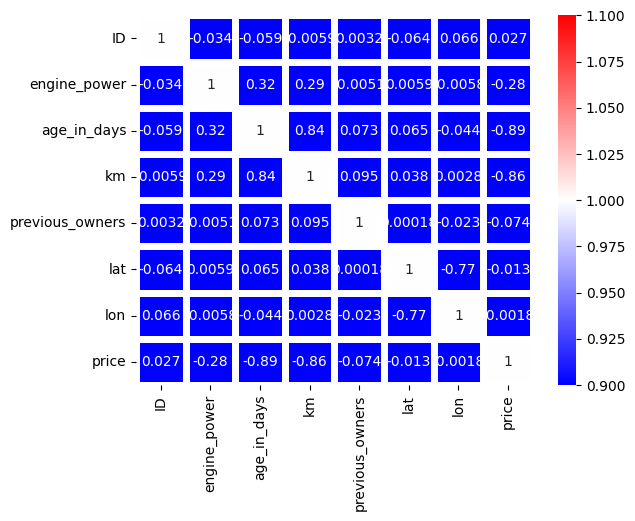

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cor_mat,vmax=1,vmin=1,annot=True,linewidths=5,cmap='bwr')

In [ ]:
data2=data.drop(['lat','ID','lon'],axis=1)

In [ ]:
data2.shape

(1520, 6)

In [ ]:
data2.head(3)

,model,engine_power,age_in_days,km,previous_owners,price
0,lounge,51,882,25000,1,8900
1,pop,51,1186,32500,1,8800
2,sport,74,4658,142228,1,4200


In [ ]:
data2=pd.get_dummies(data2,dtype=int)

In [ ]:
data2.shape

(1520, 8)

In [ ]:
data2.head(8)

,engine_power,age_in_days,km,previous_owners,price,model_lounge,model_pop,model_sport
0,51,882,25000,1,8900,1,0,0
1,51,1186,32500,1,8800,0,1,0
2,74,4658,142228,1,4200,0,0,1
3,51,2739,160000,1,6000,1,0,0
4,73,3074,106880,1,5700,0,1,0
5,74,3623,70225,1,7900,0,1,0
6,51,731,11600,1,10750,1,0,0
7,51,1521,49076,1,9190,1,0,0


In [ ]:
x=data2.drop(['price'],axis=1)
y=data2['price']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
x_train.shape

(1140, 7)

In [ ]:
y_train.shape

(1140,)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
reg=RandomForestRegressor()
n_estimators=[25,50,75,100,125,150,175,200]
criterion=['squared_error']
max_depth=[3,5,10]
parameters={'n_estimators':n_estimators,'criterion':criterion,'max_depth':max_depth}
regressor=GridSearchCV(reg,parameters)
regressor.fit(x_train,y_train)

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'criterion': ['squared_error'],
                         'max_depth': [3, 5, 10],
                         'n_estimators': [25, 50, 75, 100, 125, 150, 175, 200]})

In [ ]:
from sklearn.linear_model import LinearRegression #,ridge,lass
reg=LinearRegression() #creating object of LinearRegression
reg.fit(x_train,y_train)#training and fitting LR object using training

LinearRegression()

In [ ]:
ypred=reg.predict(x_test)

In [ ]:
ypred

array([ 9729.69625708,  9937.41126928,  6582.87129739, 10304.73464849,
        9176.17250908,  6799.38502724,  9754.52809059, 10090.96606825,
        9700.24537686,  9518.16428725,  9663.58130949,  9304.30380049,
        9482.48354786,  8664.71972622, 10413.58499596,  7217.98392994,
        6989.62597098,  9883.56145172,  9769.94282679,  7737.46544822,
        4413.96033824,  5090.41695839,  9042.24962764, 10079.4991416 ,
        9331.94014948,  8382.45531674, 10035.2280513 ,  9917.9329579 ,
       10349.95877822,  8550.20359778, 10369.60606298, 10018.19132676,
        8845.37070425,  9617.89517499,  5487.53162973,  8305.88591242,
        9759.0700114 ,  9141.26020284,  8055.20465908, 10064.7716533 ,
        6986.44184807,  7034.80950499,  5723.86516715,  9420.91716426,
        5791.41857215,  8725.74654183,  9893.94506126, 10456.07200853,
        6410.45019883, 10317.49422821,  6398.32484326, 10082.21952774,
        9885.16122012,  5496.2899651 , 10075.07311145,  9832.33860952,
      

In [ ]:
y_test

,price
461,9980
1314,9600
1472,6800
744,9890
247,10500
...,...
952,6800
1468,9980
478,9450
188,10670


In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,ypred)

0.8342208439170529

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error as mape
mape_value=mape(y_test, ypred)
mape_value

0.07945576928196096

In [ ]:
ab=9
print(ab**.5)

3.0


In [ ]:
from sklearn.metrics import mean_squared_error
t=mean_squared_error(y_test,ypred)
print(t**.5)

814.8792055118192


to find average -> sometimes the number becomes 0 then the average becomes zero so mean of the error is not possible so we move to mean squared error approach.

In [ ]:
new=[[51,2197,70000,1,1,0,0],[51,3127,100000,1,1,0,0],[51,5227,175000,3,1,0,0]]
#new=[[51,2197,7000,1,1,0,0]]
price=reg.predict(new)
price

array([7862.85093123, 6526.23943706, 3369.37924768])

In [ ]:
#Results=pd.DataFrame(columns=['Actual','Predicted'])
#Results['Actual']=y_test
Results=pd.DataFrame(columns=['Price','Predicted'])
Results['Price']=y_test
Results['Predicted']=ypred
#Results['km']=x_test['km']
Results=Results.reset_index()
Results['Id']=Results.index
Results.head(10)

,index,Price,Predicted,Id
0,461,9980,9729.696257,0
1,1314,9600,9937.411269,1
2,1472,6800,6582.871297,2
3,744,9890,10304.734648,3
4,247,10500,9176.172509,4
5,430,7950,6799.385027,5
6,939,9490,9754.528091,6
7,1490,9950,10090.966068,7
8,358,8579,9700.245377,8
9,427,9450,9518.164287,9


[]

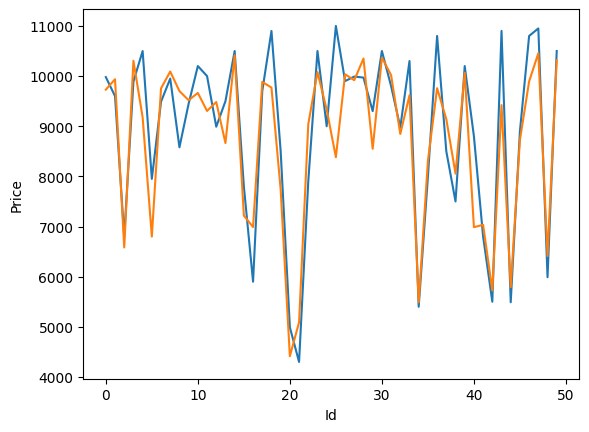

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(x='Id',y='Price',data=Results.head(50))
sns.lineplot(x='Id',y='Predicted',data=Results.head(50))
plt.plot()

[]

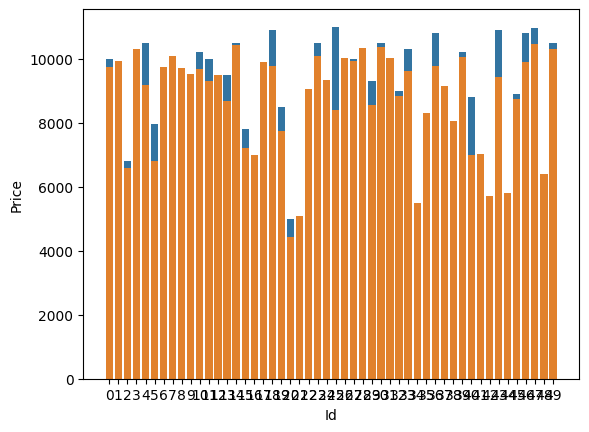

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x='Id',y='Price',data=Results.head(50))
sns.barplot(x='Id',y='Predicted',data=Results.head(50))
plt.plot()

[]

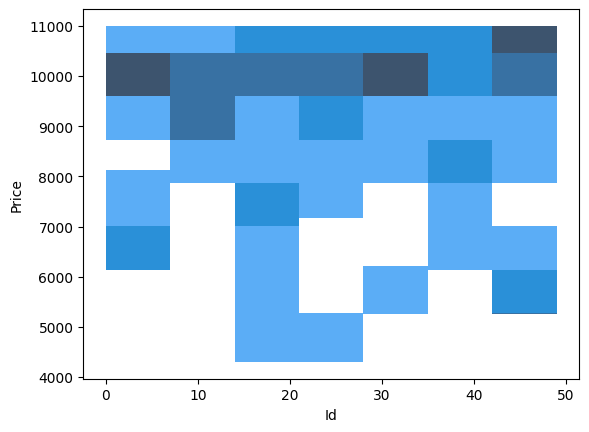

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(x='Id',y='Price',data=Results.head(50))
sns.histplot(x='Id',y='Predicted',data=Results.head(50))
plt.plot()

[]

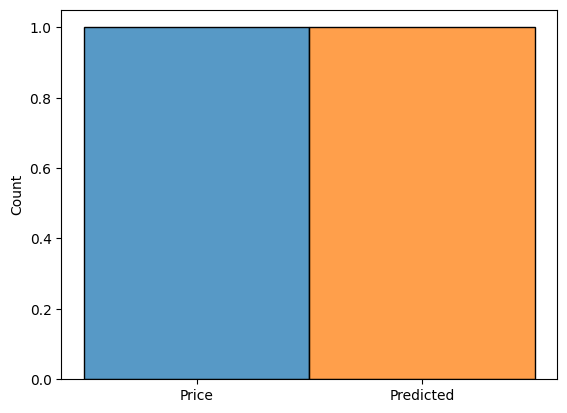

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data='Price')
sns.histplot(data='Predicted')
plt.plot()

[]

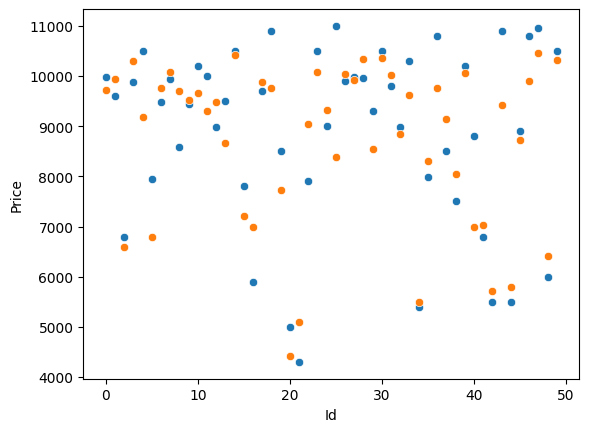

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='Id',y='Price',data=Results.head(50))
sns.scatterplot(x='Id',y='Predicted',data=Results.head(50))
plt.plot()

In [ ]:
from sklearn.model_selection import GridSearchCV
#from sklearn.grid_search import GridSearchCV
from sklearn.linear_model import Ridge
alpha=[1e-15, 1e-10,1e-8, 1e-4, 1e-3, 1e-2, 1, 5, 10, 20, 30]
ridge=Ridge()
parameters={'alpha':alpha}
ridge_regressor=GridSearchCV(ridge,parameters)
ridge_regressor.fit(x_train,y_train)

GridSearchCV(estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01, 1,
                                   5, 10, 20, 30]})

In [ ]:
ridge_regressor.best_params_

{'alpha': 20}

In [ ]:
alpha

[1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01, 1, 5, 10, 20, 30]

In [ ]:
ridge=Ridge(alpha=20)
ridge.fit(x_train,y_train)
y_pred_ridge=ridge.predict(x_test)

In [ ]:
from sklearn.metrics import mean_squared_error
Ridge_Error=mean_squared_error(y_pred_ridge,y_test)
Ridge_Error

663192.4889670564

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred_ridge)

0.8344294648067309